### Agent Graph with Loopback from Tools(ReAct Agent)

In [13]:
from pydantic import BaseModel
from typing import Literal, Dict, Any, Annotated, List
from operator import add
from jinja2 import Template
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [14]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """
    
    return f"{query} {vibe}"

In [15]:
class FinalResponse(BaseModel):
    answer: str

class State(BaseModel):
    # add is used because multiple nodes in a LangGraph workflow may update the messages field, and LangGraph needs to know how to combine those updates instead of overwriting the existing list.
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [16]:
def agent_node(state: State) -> dict:

    #jinja template
    prompt_template = """You are an assistant that is generating vibes for a user.

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
- You must return a tool call in the first interaction.
"""

    template = Template(prompt_template)
    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    #llm_with_tools 
    llm_with_tools = llm.bind_tools(
        [append_vibes, FinalResponse], #tools can be functions and pydantic model
        tool_choice="auto",
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content= prompt),
            *state.messages # message list to inject everytime we are running llm
        ]
    )

    final_answer = False
    answer= ""

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")

    return {
        "messages": [response],
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer
    }

In [17]:
def tool_router(state : State) -> str:

    if state.final_answer:
        return "end"
    elif state.iteration >2:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [18]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
# conditional part and this part creates the loop
workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

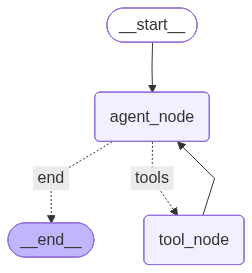

In [19]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
initial_state = {}

In [21]:
result = graph.invoke(initial_state)

In [ ]:
# LLM stopped because the tool had already been invoked, since we inject messages on every LLM cal
result

{'messages': [AIMessage(content=[{'arguments': '{"query":"Hello!","vibe":"with a cozy, futuristic glow"}', 'call_id': 'call_YoSQNtwlmLVdRtxpcMC1wz1c', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_07ac24ec1e7d7fce006a572b41764c819497519d3be0d2596c', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_07ac24ec1e7d7fce006a572b40c15c8194b212d8d3301be019', 'created_at': 1784097600.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_07ac24ec1e7d7fce006a572b40c15c8194b212d8d3301be019', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Hello!', 'vibe': 'with a cozy, futuristic glow'}, 'id': 'call_YoSQNtwlmLVdRtxpcMC1wz1c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 158, 'output_tokens': 30, 'total_tokens': 188, 'input_token_details': {'cache_read': 0}, 'output_to